In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

print("Libraries imported successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prava\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


Libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prava\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
import pandas as pd

df = pd.read_csv("Resume.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Resume.csv'

In [8]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current folder:
c:\Users\prava\OneDrive\Desktop\Resume-Screening-System

Files and folders here:
['data', 'Resume', 'resume_screening.ipynb']


In [9]:
import pandas as pd

df = pd.read_csv("Resume/Resume.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [10]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['ID', 'Resume_str', 'Resume_html', 'Category']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 77.8 KB

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [11]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [12]:
print("Categories:")
print(df["Category"].value_counts())

Categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [13]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)       # Remove HTML
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Remove numbers/symbols
    text = re.sub(r'\s+', ' ', text)         # Remove extra spaces
    return text.strip()

df["clean_resume"] = df["Resume_str"].apply(clean_text)

print(df[["Resume_str", "clean_resume"]].head())

                                          Resume_str  \
0           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1           HR SPECIALIST, US HR OPERATIONS      ...   
2           HR DIRECTOR       Summary      Over 2...   
3           HR SPECIALIST       Summary    Dedica...   
4           HR MANAGER         Skill Highlights  ...   

                                        clean_resume  
0  hr administrator marketing associate hr admini...  
1  hr specialist us hr operations summary versati...  
2  hr director summary over years experience in r...  
3  hr specialist summary dedicated driven and dyn...  
4  hr manager skill highlights hr skills hr depar...  


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["clean_resume"])
y = df["Category"]

print("TF-IDF shape:", X.shape)
print("Target shape:", y.shape)

TF-IDF shape: (2484, 5000)
Target shape: (2484,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1987, 5000)
Testing data: (497, 5000)


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.6539235412474849

Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.67      0.83      0.74        24
              ADVOCATE       0.37      0.54      0.44        24
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.67      0.21      0.32        19
                  ARTS       0.46      0.29      0.35        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.86      0.75      0.80        24
               BANKING       0.79      0.65      0.71        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.46      0.79      0.58        24
                  CHEF       0.81      0.71      0.76        24
          CONSTRUCTION       0.82      0.82      0.82        22
            CONSULTANT       0.44      0.17      0.25        23
              DESIGNER       0.84      0.76 

c:\Users\prava\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\prava\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\prava\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [18]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [19]:
df = pd.read_csv("Resume/Resume.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [20]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['ID', 'Resume_str', 'Resume_html', 'Category']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 77.8 KB

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [21]:
print("Number of categories:", df["Category"].nunique())

print("\nResume categories:")
print(df["Category"].value_counts())

Number of categories: 24

Resume categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [22]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_resume"] = df["Resume_str"].apply(clean_text)

df[["Resume_str", "clean_resume"]].head()

,Resume_str,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [23]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["clean_resume"])
y = df["Category"]

print("TF-IDF shape:", X.shape)
print("Target shape:", y.shape)

TF-IDF shape: (2484, 5000)
Target shape: (2484,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1987, 5000)
Testing data: (497, 5000)


In [25]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [26]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.6539235412474849

Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.67      0.83      0.74        24
              ADVOCATE       0.37      0.54      0.44        24
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.67      0.21      0.32        19
                  ARTS       0.46      0.29      0.35        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.86      0.75      0.80        24
               BANKING       0.79      0.65      0.71        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.46      0.79      0.58        24
                  CHEF       0.81      0.71      0.76        24
          CONSTRUCTION       0.82      0.82      0.82        22
            CONSULTANT       0.44      0.17      0.25        23
              DESIGNER       0.84      0.76 

c:\Users\prava\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\prava\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\prava\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

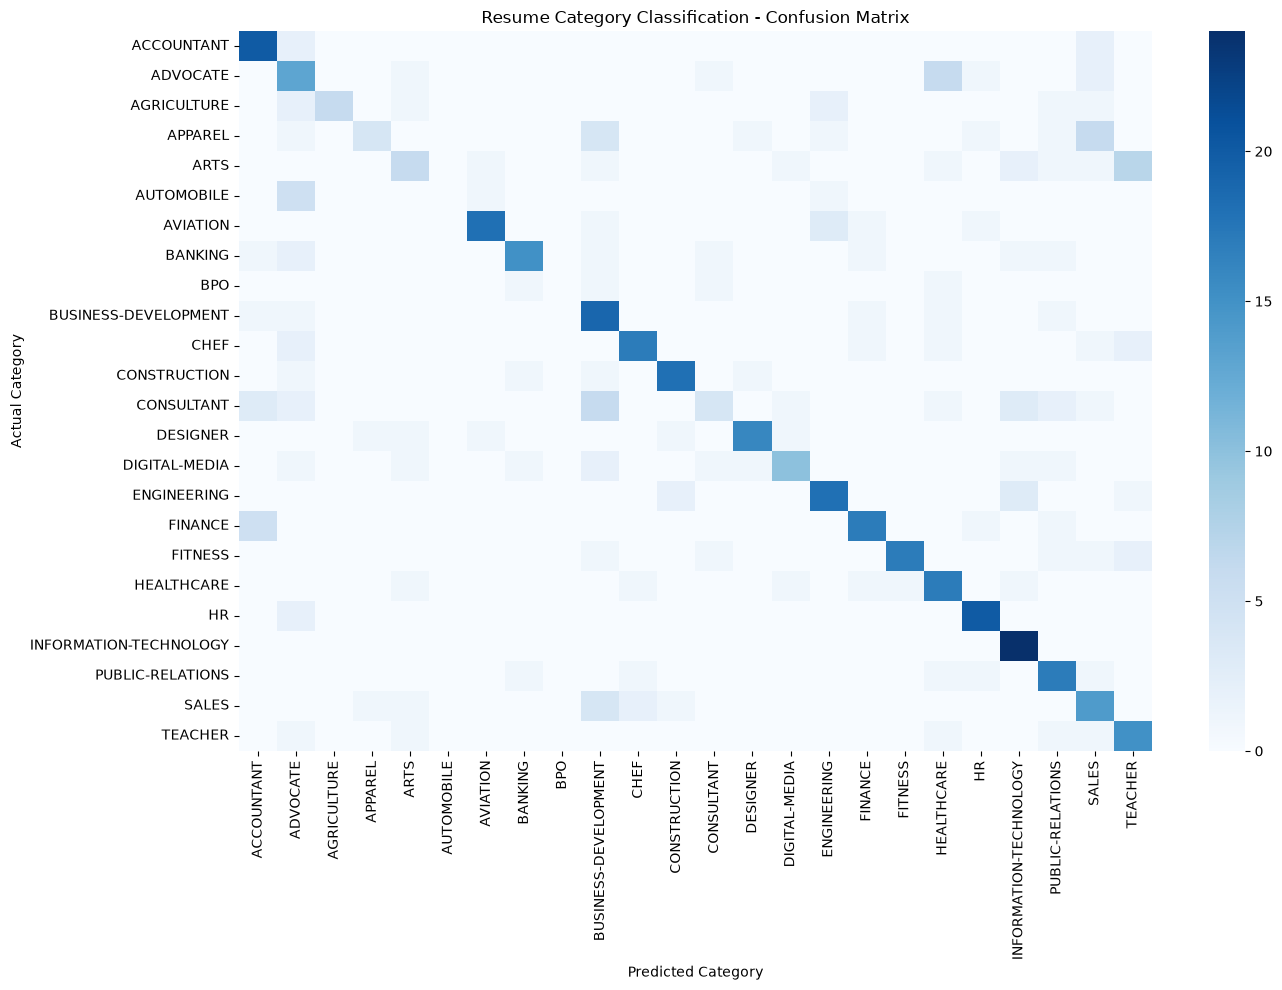

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Resume Category Classification - Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [28]:
with open("job_description.txt", "r", encoding="utf-8") as file:
    job_description = file.read()

print(job_description)

Data Engineer

We are looking for a Data Engineer with experience in Python, SQL,
databases, ETL, data pipelines, data warehousing, Apache Spark,
AWS, Git, Linux and Pandas.

Required skills:
Python, SQL, MySQL, PostgreSQL, ETL, Data Warehousing,
Apache Spark, AWS, Git, Linux, Pandas.

Responsibilities include developing data pipelines, performing ETL,
working with databases, maintaining data warehouses and processing
large datasets.


In [29]:
clean_job_description = clean_text(job_description)

print(clean_job_description)

data engineer we are looking for a data engineer with experience in python sql databases etl data pipelines data warehousing apache spark aws git linux and pandas required skills python sql mysql postgresql etl data warehousing apache spark aws git linux pandas responsibilities include developing data pipelines performing etl working with databases maintaining data warehouses and processing large datasets


In [30]:
required_skills = [
    "python",
    "sql",
    "mysql",
    "postgresql",
    "pandas",
    "numpy",
    "etl",
    "data warehouse",
    "data warehousing",
    "data pipeline",
    "data pipelines",
    "apache spark",
    "spark",
    "aws",
    "azure",
    "gcp",
    "git",
    "linux",
    "docker",
    "kafka",
    "airflow",
    "mongodb"
]

print("Required skills:")
print(required_skills)

Required skills:
['python', 'sql', 'mysql', 'postgresql', 'pandas', 'numpy', 'etl', 'data warehouse', 'data warehousing', 'data pipeline', 'data pipelines', 'apache spark', 'spark', 'aws', 'azure', 'gcp', 'git', 'linux', 'docker', 'kafka', 'airflow', 'mongodb']


In [31]:
def extract_skills(text, skill_list):
    text = str(text).lower()

    found_skills = []

    for skill in skill_list:
        if skill.lower() in text:
            found_skills.append(skill)

    return list(set(found_skills))

In [32]:
df["Skills"] = df["Resume_str"].apply(
    lambda x: extract_skills(x, required_skills)
)

df[["Category", "Skills"]].head()

,Category,Skills
0,HR,[aws]
1,HR,[git]
2,HR,[]
3,HR,[]
4,HR,[aws]


In [33]:
job_skills = extract_skills(
    job_description,
    required_skills
)

print("Required skills found in job description:")
print(job_skills)

Required skills found in job description:
['mysql', 'apache spark', 'aws', 'data warehousing', 'etl', 'data warehouse', 'linux', 'pandas', 'sql', 'python', 'git', 'data pipeline', 'postgresql', 'data pipelines', 'spark']


In [34]:
matching_documents = [clean_job_description] + df["clean_resume"].tolist()

matching_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

matching_matrix = matching_vectorizer.fit_transform(
    matching_documents
)

job_vector = matching_matrix[0]

resume_vectors = matching_matrix[1:]

similarity_scores = cosine_similarity(
    job_vector,
    resume_vectors
).flatten()

df["Similarity_Score"] = similarity_scores * 100

df[["Category", "Similarity_Score"]].head()

,Category,Similarity_Score
0,HR,1.756420
1,HR,0.199340
2,HR,1.177684
3,HR,0.229983
4,HR,0.635141


In [35]:
def calculate_skill_match(candidate_skills, required_skills):

    if len(required_skills) == 0:
        return 0

    matched_skills = set(candidate_skills).intersection(
        set(required_skills)
    )

    return (len(matched_skills) / len(required_skills)) * 100

In [36]:
df["Skill_Match_Score"] = df["Skills"].apply(
    lambda x: calculate_skill_match(x, job_skills)
)

df[["Category", "Skill_Match_Score"]].head()

,Category,Skill_Match_Score
0,HR,6.666667
1,HR,6.666667
2,HR,0.000000
3,HR,0.000000
4,HR,6.666667


In [37]:
def find_missing_skills(candidate_skills, required_skills):

    return list(
        set(required_skills) - set(candidate_skills)
    )

In [38]:
df["Missing_Skills"] = df["Skills"].apply(
    lambda x: find_missing_skills(x, job_skills)
)

df[["Category", "Skills", "Missing_Skills"]].head()

,Category,Skills,Missing_Skills
0,HR,[aws],"[mysql, data warehousing, etl, data warehouse,..."
1,HR,[git],"[mysql, aws, data warehousing, etl, data wareh..."
2,HR,[],"[mysql, aws, data warehousing, etl, data wareh..."
3,HR,[],"[mysql, aws, data warehousing, etl, data wareh..."
4,HR,[aws],"[mysql, data warehousing, etl, data warehouse,..."


In [39]:
df["Final_Score"] = (
    df["Similarity_Score"] * 0.7 +
    df["Skill_Match_Score"] * 0.3
)

df[[
    "Category",
    "Similarity_Score",
    "Skill_Match_Score",
    "Final_Score"
]].head()

,Category,Similarity_Score,Skill_Match_Score,Final_Score
0,HR,1.756420,6.666667,3.229494
1,HR,0.199340,6.666667,2.139538
2,HR,1.177684,0.000000,0.824379
3,HR,0.229983,0.000000,0.160988
4,HR,0.635141,6.666667,2.444599


In [40]:
ranking = df.sort_values(
    by="Final_Score",
    ascending=False
).reset_index(drop=True)

ranking["Rank"] = ranking.index + 1

In [41]:
final_result = ranking[
    [
        "Rank",
        "Category",
        "Final_Score",
        "Similarity_Score",
        "Skill_Match_Score",
        "Missing_Skills"
    ]
]

final_result.head(20)

,Rank,Category,Final_Score,Similarity_Score,Skill_Match_Score,Missing_Skills
0,1,AUTOMOBILE,40.324503,46.177861,26.666667,"[mysql, aws, linux, pandas, git, python, data ..."
1,2,INFORMATION-TECHNOLOGY,31.924899,25.606999,46.666667,"[mysql, pandas, git, data pipeline, data pipel..."
2,3,DIGITAL-MEDIA,26.408639,23.440913,33.333333,"[aws, data warehousing, data warehouse, linux,..."
3,4,AUTOMOBILE,26.333462,20.476374,40.000000,"[aws, data warehousing, etl, data warehouse, l..."
4,5,ENGINEERING,25.782294,22.546134,33.333333,"[mysql, aws, etl, linux, git, data pipeline, d..."
5,6,AGRICULTURE,25.013664,21.448092,33.333333,"[mysql, data warehousing, etl, data warehouse,..."
6,7,CONSULTANT,24.542842,23.632631,26.666667,"[aws, data warehousing, etl, linux, pandas, gi..."
7,8,DESIGNER,21.426169,19.180241,26.666667,"[aws, data warehousing, etl, data warehouse, p..."
8,9,CONSULTANT,21.269821,21.814030,20.000000,"[mysql, aws, data warehousing, linux, pandas, ..."
9,10,INFORMATION-TECHNOLOGY,20.912395,21.303421,20.000000,"[mysql, data warehousing, etl, data warehouse,..."


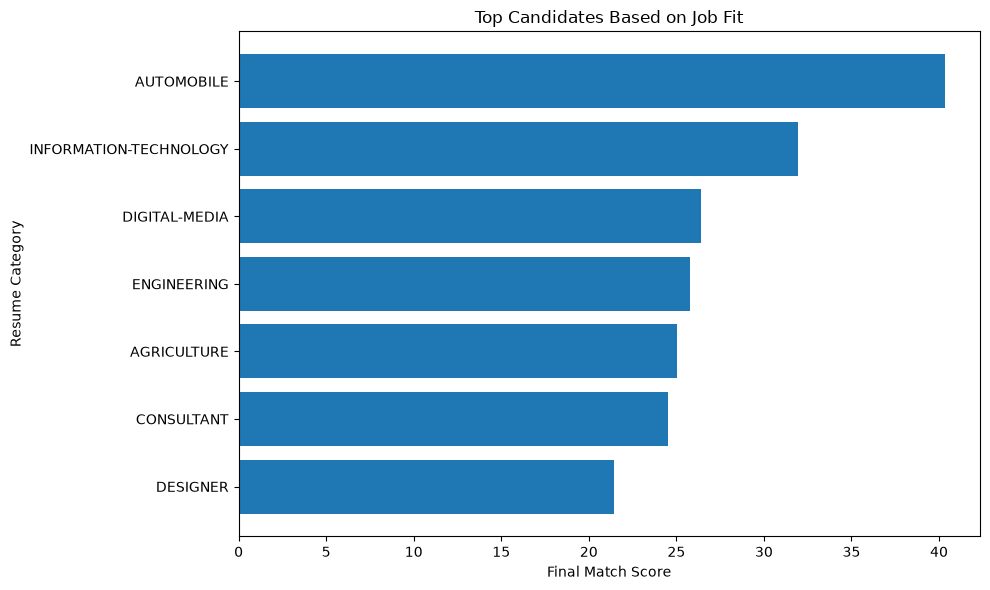

In [42]:
top_candidates = ranking.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top_candidates["Category"],
    top_candidates["Final_Score"]
)

plt.xlabel("Final Match Score")
plt.ylabel("Resume Category")
plt.title("Top Candidates Based on Job Fit")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

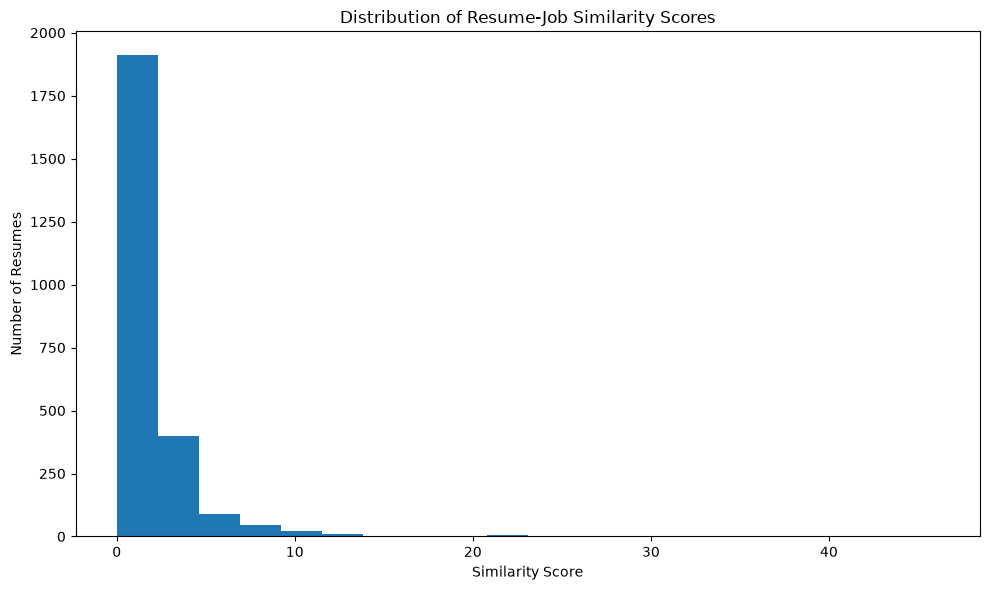

In [43]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Similarity_Score"],
    bins=20
)

plt.xlabel("Similarity Score")
plt.ylabel("Number of Resumes")
plt.title("Distribution of Resume-Job Similarity Scores")

plt.tight_layout()
plt.show()

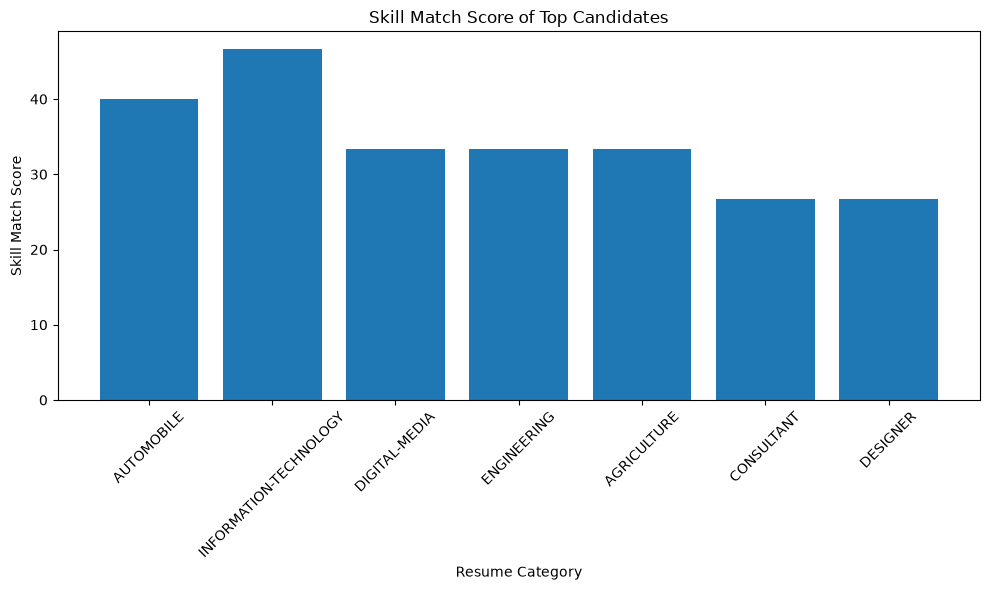

In [44]:
top_skill_candidates = ranking.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_skill_candidates["Category"],
    top_skill_candidates["Skill_Match_Score"]
)

plt.xlabel("Resume Category")
plt.ylabel("Skill Match Score")
plt.title("Skill Match Score of Top Candidates")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [45]:
final_result.to_csv(
    "candidate_ranking_results.csv",
    index=False
)

print("Candidate ranking saved successfully!")

Candidate ranking saved successfully!


In [46]:
print("Top 10 Candidates:")
display(
    final_result.head(10)
)

Top 10 Candidates:


,Rank,Category,Final_Score,Similarity_Score,Skill_Match_Score,Missing_Skills
0,1,AUTOMOBILE,40.324503,46.177861,26.666667,"[mysql, aws, linux, pandas, git, python, data ..."
1,2,INFORMATION-TECHNOLOGY,31.924899,25.606999,46.666667,"[mysql, pandas, git, data pipeline, data pipel..."
2,3,DIGITAL-MEDIA,26.408639,23.440913,33.333333,"[aws, data warehousing, data warehouse, linux,..."
3,4,AUTOMOBILE,26.333462,20.476374,40.000000,"[aws, data warehousing, etl, data warehouse, l..."
4,5,ENGINEERING,25.782294,22.546134,33.333333,"[mysql, aws, etl, linux, git, data pipeline, d..."
5,6,AGRICULTURE,25.013664,21.448092,33.333333,"[mysql, data warehousing, etl, data warehouse,..."
6,7,CONSULTANT,24.542842,23.632631,26.666667,"[aws, data warehousing, etl, linux, pandas, gi..."
7,8,DESIGNER,21.426169,19.180241,26.666667,"[aws, data warehousing, etl, data warehouse, p..."
8,9,CONSULTANT,21.269821,21.814030,20.000000,"[mysql, aws, data warehousing, linux, pandas, ..."
9,10,INFORMATION-TECHNOLOGY,20.912395,21.303421,20.000000,"[mysql, data warehousing, etl, data warehouse,..."


## Project Summary

This project developed an NLP-based Resume Screening and Candidate Ranking System for a Data Engineer job role.

The system processes resume text, extracts relevant skills, compares resumes with the given job description, calculates a job-fit score, ranks candidates, and identifies missing skills.

### Key Components

* Resume text preprocessing
* Skill extraction
* TF-IDF feature extraction
* Resume-to-job cosine similarity
* Skill matching
* Candidate scoring
* Candidate ranking
* Missing skill identification
* Resume category classification
* Model evaluation and visualization

### Scoring Method

The final candidate score is calculated using:

**Final Score = 70% Resume-Job Similarity + 30% Skill Match Score**

This provides an explainable ranking based on both overall resume relevance and required skills.

### Business Value

The system can support recruiters by reducing manual resume screening, identifying relevant candidates faster, comparing candidates consistently, and highlighting missing skills.

### Conclusion

The project demonstrates how Natural Language Processing and Machine Learning techniques can be applied to automate and support the initial stages of the recruitment process.
